## Business Understanding

We want to predict which train stations are most vulnerable to which meteorological phenomena in Finland. Our goal is to cluster train stations by the amount of delay associated with a weather phenomena. The study is done for educational purposes and there is no real-world motivation. The assumption is that weather causes delays and that some stations are more prone to delays caused or associated different weather phenomena such as rain or freezing temperatures. The plan is to first extract the data from Kaggle, understand the data, prepare the data, model and evaluate. 

## Data Understanding

The data is pulled from Kaggle using Python. The data consists of Finnish railway operational data paired with meteorological observations for delay prediction. The data is filled with records containing a single timetable event `Arrival / Departure` of long-distance VR-trains at stations as well as the weather observation from the nearest weather station at the time of the stop.

[Link to Data (www.kaggle.com)](https://www.kaggle.com/datasets/viniborin/finland-integrated-train-weather-dataset-fi-tw)

Period: 2018–2025 | Records: ~48 million | Columns: up to 125 | Sources: Digitraffic + Finnish Meteorological Institute

> **Note:** All exploration below is based on a single month of data. This sample is used only to understand the data's structure and quality and the full date range will be used for modeling.

In [8]:
import kagglehub
import pandas as pd

#download the dataset from Kaggle using the kagglehub library
path = kagglehub.dataset_download("viniborin/finland-integrated-train-weather-dataset-fi-tw")

In [9]:
from pathlib import Path

#import the dataset
file = Path(path) / "matched_data_flat_2025_10.parquet"
metadata_file = Path(path) / "metadata_train_stations.csv"

#read the parquet file into a pandas dataframe
df = pd.read_parquet(file)

#List the available columns in the dataset
for i, (col, dtype) in enumerate(zip(df.columns, df.dtypes), 1):
    print(f"{i:>3}. {col:<45} {dtype}")

  1. trainNumber                                   int64
  2. departureDate                                 str
  3. operatorUICCode                               int64
  4. operatorShortCode                             str
  5. trainType                                     str
  6. trainCategory                                 str
  7. commuterLineID                                float64
  8. runningCurrently                              bool
  9. cancelled                                     bool
 10. version                                       int64
 11. timetableType                                 str
 12. timetableAcceptanceDate                       str
 13. stationName                                   str
 14. stationShortCode                              str
 15. stationUICCode                                int64
 16. countryCode                                   str
 17. type                                          str
 18. trainStopping                                 

In total we have 123 columns of data in this dataset. We have all the necessary features to correctly associate station delays with weather phenomena. We have different weather data for the time of the stop and also rolling-window aggregates 12h/24h/72h from the time of the stop. We will be using only the instantaneous weather observations for this study. In addition we have necessary information for training such as the delayed time, causes for delay, station data and train data. The next step is to extract and prepare only the necessary data needed to train the model.

In [10]:
df.describe(include='all')

,trainNumber,departureDate,operatorUICCode,operatorShortCode,trainType,trainCategory,commuterLineID,runningCurrently,cancelled,version,...,Precipitation amount (12h mean),Precipitation amount (12h cumulative),Precipitation amount (24h mean),Precipitation amount (24h cumulative),Precipitation amount (72h mean),Precipitation amount (72h cumulative),estimateSource,liveEstimateTime,unknownDelay,unknownTrack
count,537724.000000,537724,537724.000000,537724,537724,537724,0.0,537724,537724,5.377240e+05,...,537724.000000,537724.000000,537724.000000,537724.000000,537724.000000,537724.000000,31276,31253,6687,390
unique,NaN,31,NaN,6,8,1,NaN,2,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2,20886,2,2
top,NaN,2025-10-17,NaN,vr,IC,Long-distance,NaN,False,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,LIIKE_AUTOMATIC,2025-10-03T18:17:00.000Z,False,True
freq,NaN,19226,NaN,536846,367444,537724,NaN,537540,536382,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,28973,6,6418,376
mean,324.708620,NaN,16.441762,NaN,NaN,NaN,NaN,NaN,NaN,2.924115e+11,...,0.085474,1.996041,0.086157,4.043114,0.078725,11.097153,NaN,NaN,NaN,NaN
std,1059.410042,NaN,181.100603,NaN,NaN,NaN,NaN,NaN,NaN,7.827937e+07,...,0.172391,4.027823,0.146912,6.882475,0.103923,14.614362,NaN,NaN,NaN,NaN
min,1.000000,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.922838e+11,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,35.000000,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.923508e+11,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,70.000000,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.924087e+11,...,0.000000,0.000000,0.010000,0.400000,0.030000,4.200000,NaN,NaN,NaN,NaN
75%,269.000000,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.924697e+11,...,0.090000,2.000000,0.110000,5.400000,0.130000,18.200000,NaN,NaN,NaN,NaN


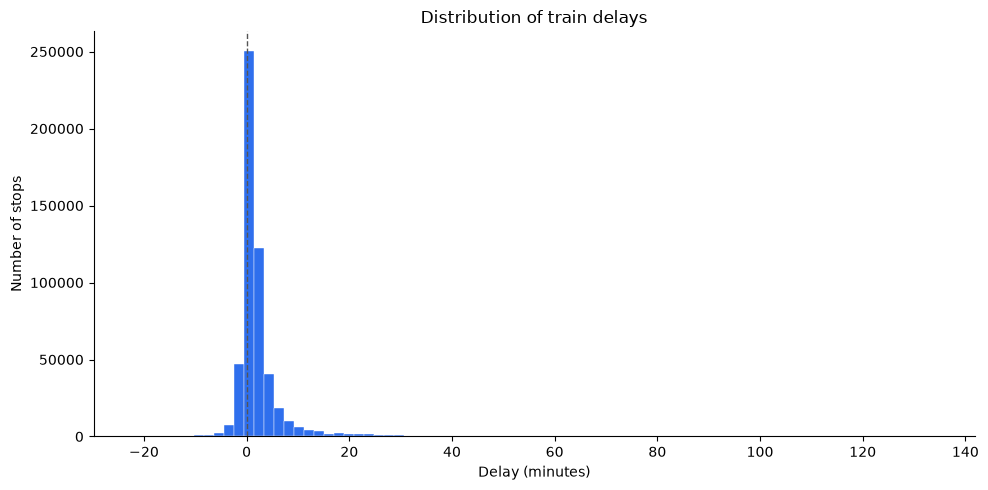

In [11]:
import matplotlib.pyplot as plt

#plot the distribution of train delays, clipped to the 0.1-99.9th percentile to avoid extreme outliers squashing the view
delay = df['differenceInMinutes'].dropna()
lower, upper = delay.quantile([0.001, 0.999])

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(delay.clip(lower, upper), bins=80, color='#2F6FED', edgecolor='white', linewidth=0.3)
ax.axvline(0, color='#555555', linewidth=1, linestyle='--')
ax.set_title('Distribution of train delays')
ax.set_xlabel('Delay (minutes)')
ax.set_ylabel('Number of stops')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

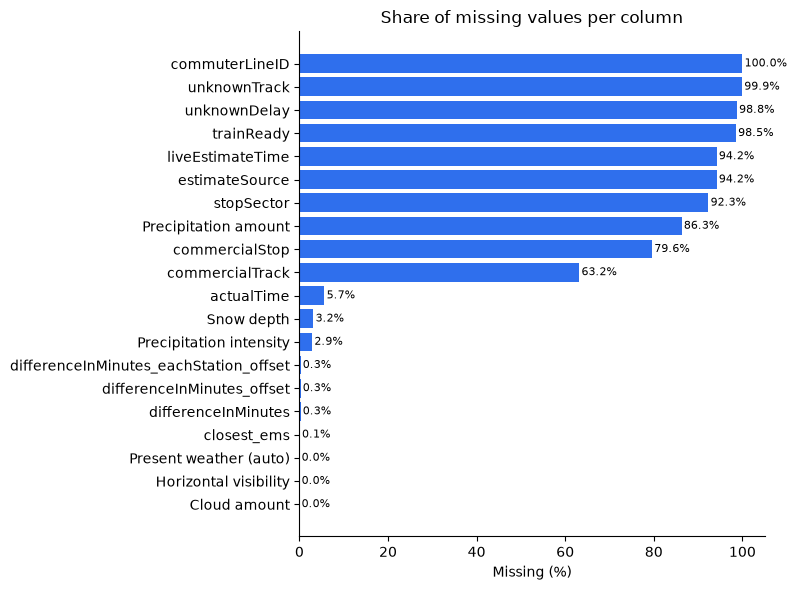

In [12]:
#data quality: share of missing values per column, only columns with at least one missing value
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * len(missing_pct))))
ax.barh(missing_pct.index[::-1], missing_pct.values[::-1], color='#2F6FED')
for y, v in enumerate(missing_pct.values[::-1]):
    ax.text(v + 0.5, y, f'{v:.1f}%', va='center', fontsize=8)
ax.set_xlim(0, 105)
ax.set_xlabel('Missing (%)')
ax.set_title('Share of missing values per column')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

We see the share of missing values per column is unusually high for Precipitation Amount, which is a feature we need for training. We need to make sure that a NaN value means that no precipitation was recorded at the time of the stop. Also features we need such as snow depth and precipitation intensity both have over 4% of missing data. 

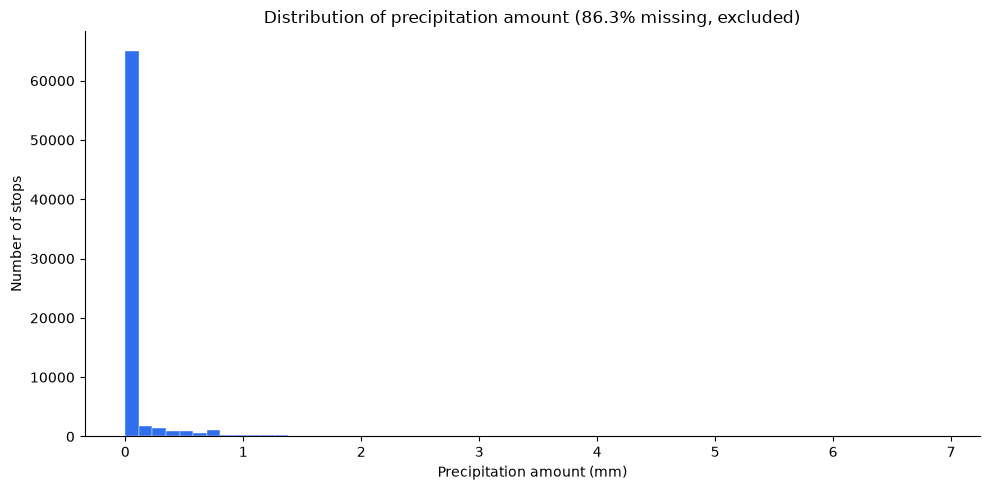

In [13]:
#plot the distribution of precipitation amount (missing values excluded, noted in the title)
precip = df['Precipitation amount']
missing_share = precip.isna().mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(precip.dropna(), bins=60, color='#2F6FED', edgecolor='white', linewidth=0.3)
ax.set_title(f'Distribution of precipitation amount ({missing_share:.1f}% missing, excluded)')
ax.set_xlabel('Precipitation amount (mm)')
ax.set_ylabel('Number of stops')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [14]:
precip = df['Precipitation amount']

print(f"Exactly 0.0: {(precip == 0).sum():,} ({(precip == 0).mean()*100:.1f}%)")
print(f"Non-null and non-zero: {((precip.notna()) & (precip != 0)).sum():,}")
print()
print("Null values:")
print(f"Total null values: {precip.isna().sum():,} ({precip.isna().mean()*100:.1f}%)")
print()
print("Top 10 most common non-null values:")
print(precip.value_counts(dropna=True).head(10))

Exactly 0.0: 61,291 (11.4%)
Non-null and non-zero: 12,451

Null values:
Total null values: 463,982 (86.3%)

Top 10 most common non-null values:
Precipitation amount
0.0    61291
0.1     3775
0.2     1840
0.3     1374
0.4      954
0.5      905
0.7      592
0.6      566
0.8      429
1.0      315
Name: count, dtype: int64


As we can see the missing values do not mean that there was 0 mm of precipitation. They are missing values and the whole column should be deleted because most of the data is missing (86%).

## Data Preparation

We will now proceed to select only the necessary columns needed for training and cleaning the data from selected features. 

We decided to use the following features for training:

- `stationShortCode` - the station, used for grouping/clustering
- `scheduledTime` - used to derive month/season and hour-of-day features
- `differenceInMinutes` - the target variable (delay)
- `causes` - official delay cause codes, used to check whether weather is ever recorded as a cause
- `Air temperature`
- `Wind speed`
- `Relative humidity`
- `Precipitation intensity`
- `Snow depth`
- `Pressure (msl)`
- `Horizontal visibility`
- `Cloud amount`
- `Present weather (auto)` - coded weather phenomenon observed at the time of the stop

We dropped the 12h/24h/72h rolling-window aggregates (90 columns) since we only need the instantaneous observations, `Precipitation amount` (86% missing), `Dew-point temperature` (redundant with temperature + humidity), `Wind direction` and `Gust speed` (low priority, not needed for this study), and all operational/administrative columns not related to weather or delay (train numbers, operator codes, timetable metadata, etc.).

In [17]:
selected_cols = [
    'stationShortCode',
    'scheduledTime',
    'differenceInMinutes',
    'causes',
    'Air temperature',
    'Wind speed',
    'Relative humidity',
    'Precipitation intensity',
    'Snow depth',
    'Pressure (msl)',
    'Horizontal visibility',
    'Cloud amount',
    'Present weather (auto)',
]

#read only the selected columns directly from the parquet file (columnar format, so this skips loading the rest)
df_selected = pd.read_parquet(file, columns=selected_cols)

#downcast floats to save memory, and turn the repeat-heavy station code into a category
float_cols = df_selected.select_dtypes(include='float64').columns
df_selected[float_cols] = df_selected[float_cols].astype('float32')
df_selected['stationShortCode'] = df_selected['stationShortCode'].astype('category')

After extracting only the columns we need and downcasting, we are able to import the whole 96 months of data to our system.